Summarize the notebook

what is input and output to this notebook. frorm where the input were generated

do we need to run any previous notebook before running this one

discuss the method

name all the models

discuss the result that we get

make a discussion on the result. how it improved compared to baseline model of gloabl popularity to discover new product

give a summary of the functions used in this notebook

## Importing Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import os

from tqdm.auto import tqdm
from collections import defaultdict

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

from scipy.sparse import csr_matrix

from mlxtend.frequent_patterns import fpgrowth, association_rules

from itertools import combinations

from implicit.als import AlternatingLeastSquares

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import lightgbm as lgb

import time

import gc

In [2]:
df_calib = pd.read_csv('data/working_data/calib_all_transaction.csv')
df_holdout = pd.read_csv('data/given_data/holdout_transaction.csv')
df_catalog_calib = pd.read_csv('data/given_data/prod_catalog_calib.csv')
df_catalog_holdout = pd.read_csv('data/given_data/prod_catalog_holdout.csv')

df_calib['Invoice'] = df_calib['Invoice'].astype(str).str.upper().str.strip()
df_calib['InvoiceDate'] = pd.to_datetime(df_calib['InvoiceDate'])
df_calib["Customer_ID"] = df_calib["Customer_ID"].astype("Int64")

df_holdout['Invoice'] = df_holdout['Invoice'].astype(str).str.upper().str.strip()
df_holdout['InvoiceDate'] = pd.to_datetime(df_holdout['InvoiceDate'])
df_holdout["Customer_ID"] = df_holdout["Customer_ID"].astype("Int64")

print('df_calib')
df_calib.info()

print('df_holdout')
df_holdout.info()

print('df_catalog_calib')
df_catalog_calib.info()

print('df_catalog_holdout')
df_catalog_holdout.info()

df_calib
<class 'pandas.DataFrame'>
RangeIndex: 475984 entries, 0 to 475983
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      475984 non-null  str           
 1   StockCode    475984 non-null  str           
 2   Quantity     475984 non-null  float64       
 3   line_amount  475984 non-null  float64       
 4   Description  475984 non-null  str           
 5   InvoiceDate  475984 non-null  datetime64[us]
 6   Customer_ID  379569 non-null  Int64         
 7   Country      475984 non-null  str           
 8   Price        475984 non-null  float64       
dtypes: Int64(1), datetime64[us](1), float64(3), str(4)
memory usage: 33.1 MB
df_holdout
<class 'pandas.DataFrame'>
RangeIndex: 509276 entries, 0 to 509275
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      509276 non-null  str           
 1  

## Customer Segmentation

fill cell:

discuss why custoemr segmentation is required

discuss our method to determine segmentation and score


In [3]:
# ==========================================================
# Segnmenting customers based on how often a customer buy a new product
# To measure such behavior, I calculate a new metric named 'product_transition_rate' from calibration/ train data
# For each customer:
#   - sort invoices chronologically
#   - first invoice is used only to initialize history and product transition rate calculated from invoice 2 to n    
# Outputs: df_transition_rate
# ==========================================================

def customer_segmentation(df_history):

    # Build invoice-level baskets: one row per customer-invoice-date
    df_invoice_level = (
        df_history.groupby(["Customer_ID", "Invoice", "InvoiceDate"], as_index=False)["StockCode"]
          .agg(lambda s: set(s))
          .rename(columns={"StockCode": "product_set"})
    )
    
    # Sort chronologically within each customer
    df_invoice_level = df_invoice_level.sort_values(
        ["Customer_ID", "InvoiceDate", "Invoice"]
    ).reset_index(drop=True)
    
    invoice_results = []
    transition_rate = []
    
    for customer_id, invoice in df_invoice_level.groupby("Customer_ID", sort=False):
        product_set_cumul = set()
        individual_metric = []
    
        invoice = (
            invoice
            .sort_values(["InvoiceDate", "Invoice"])
            .reset_index(drop=True)
        )
        
        for invoice_pos, row in invoice.iterrows():
            invoice_size = len(row["product_set"])
    
            # Skip scoring the first invoice because there is no history history
            if len(product_set_cumul) > 0 and invoice_size > 0:
                new_products = row["product_set"] - product_set_cumul
                
                # invoice_pos = 1 for second invoice, 2 for third, ...
                weight = 3.3 - 2.2 * np.exp(-0.1 * invoice_pos)
                
                individual_metric.append(weight * len(new_products) / invoice_size)
    
            # Update product_set_cumul after scoring; update operation on the set work like an union
            product_set_cumul.update(row["product_set"])
    
        product_transition_rate = np.mean(individual_metric) if len(individual_metric) > 0 else np.nan
    
        transition_rate.append({
            "Customer_ID": customer_id,
            "number_of_invoice": invoice_pos+1,
            "product_transition_rate": product_transition_rate
        })
    
    # Final outputs
    df_transition_rate = pd.DataFrame(transition_rate).sort_values(
        "product_transition_rate", ascending=False
    ).reset_index(drop=True)
    
    # ==========================================================
    # Customer segmentation by product_transition_rate
    # similar product shoppers (dynamic shopper)   : product_transition_rate < 0.65 (>=0.65); 
    # infrequent shopper: product_transition_rate is null / unknown
    # ==========================================================
    
    threshold = 0.65
    
    df_transition_rate["shopper_type"] = np.select(
        [
            df_transition_rate["product_transition_rate"].isna(),
            df_transition_rate["product_transition_rate"] < threshold,
            df_transition_rate["product_transition_rate"] >= threshold,
        ],
        [
            "infrequent_shopper",
            "similar_prod_shoppers",
            "product_explorer",
        ],
        default="infrequent_shopper"
    )
    
    similar_prod_shoppers = set(
        df_transition_rate.loc[
            df_transition_rate["shopper_type"] == "similar_prod_shoppers",
            "Customer_ID"
        ]
    )
    
    product_explorers = set(
        df_transition_rate.loc[
            df_transition_rate["shopper_type"] == "product_explorer",
            "Customer_ID"
        ]
    )
    
    infrequent_shoppers = set(
        df_transition_rate.loc[
            df_transition_rate["shopper_type"] == "infrequent_shopper",
            "Customer_ID"
        ]
    )

    return similar_prod_shoppers, product_explorers, infrequent_shoppers, df_transition_rate



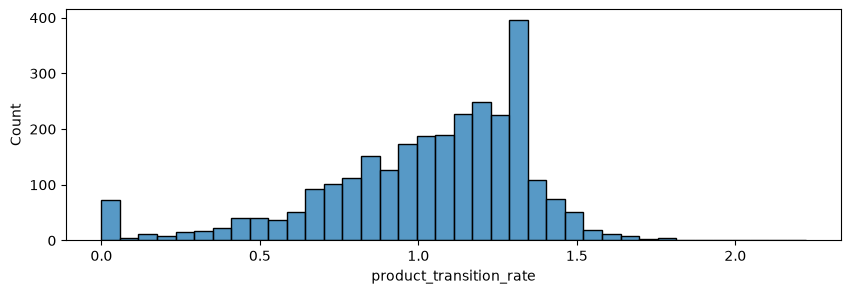

In [4]:
_,_,_,df_transition_rate = customer_segmentation(df_calib )

plt.figure(figsize=(10,3))
sns.histplot(df_transition_rate['product_transition_rate'])
plt.show()



fill cell

explain the result the above graph

why there is large count on 0 product rtransition rate





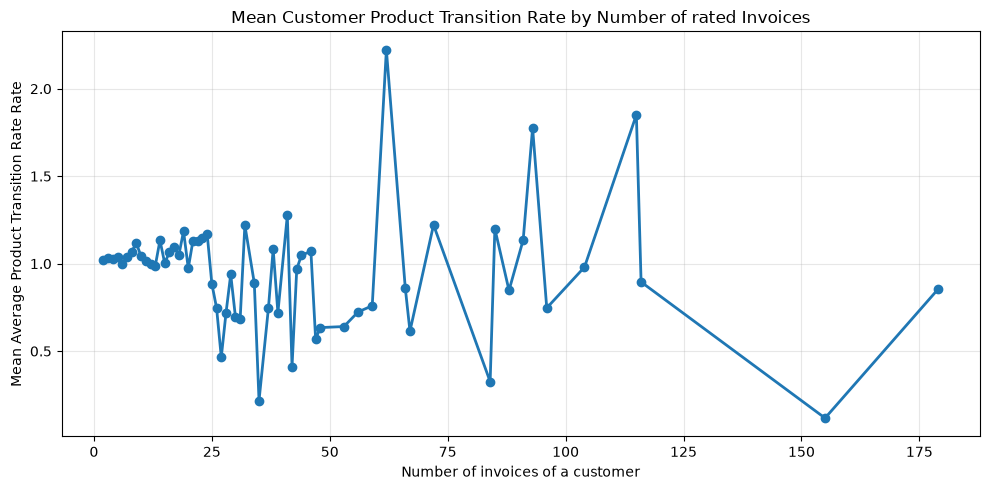

   number_of_invoice  average_product_transition_rate  num_customers
0                  2                         1.022010            819
1                  3                         1.031529            509
2                  4                         1.027999            376
3                  5                         1.038375            241
4                  6                         0.998496            185


In [5]:
# ==========================================================
# Mean Product Transition Rate by number of rated invoices
# ==========================================================

plot_df = (
    df_transition_rate
    .dropna(subset=["product_transition_rate"])
    .groupby("number_of_invoice", as_index=False)
    .agg(
        average_product_transition_rate=("product_transition_rate", "mean"),
        num_customers=("Customer_ID", "count")
    )
)

plt.figure(figsize=(10, 5))
plt.plot(
    plot_df["number_of_invoice"],
    plot_df["average_product_transition_rate"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of invoices of a customer")
plt.ylabel("Mean Average Product Transition Rate Rate")
plt.title("Mean Customer Product Transition Rate by Number of rated Invoices")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: inspect the aggregated data
print(plot_df.head())

fill cell

dsicuss the result

above graph shows that product transition rate do not have a biasness on the number of invoices. if it were not flat that means the way defined was wrong. but I am poroved right as it is not deviating upward or downward

## Adding embedding using sentence transformer

fill cell

summarize this section

why this embedding is required

In [6]:
### Creating short description using product table

def short_descript(text):
    text = str(text).lower()

    # remove numbers and measurements
    text = re.sub(r'\b\d+\s*(cm|mm|m|inch|inches|oz|ml|l|kg|g)\b', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)

    # remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # words that usually do not define category
    noise_words = {
        'set', 'pack', 'piece', 'pieces', 'small', 'large', 'medium',
        'mini', 'big', 'assorted', 'colour', 'colours', 'red', 'blue',
        'green', 'pink', 'white', 'black', 'yellow', 'purple', 'orange',
        'brown', 'silver', 'gold', 'metal', 'wooden', 'wood', 'glass',
        'ceramic', 'paper', 'plastic', 'felt', 'cotton', 'cm', 'mm',
        'round', 'square', 'heart', 'star', 'vintage', 'retro'
    }

    words = text.split()
    words = [w for w in words if w not in noise_words]

    return ' '.join(words)

def short_descript_v2(text):
    text = str(text).lower()

    # Remove measurements like 30cm, 500ml, 2kg
    text = re.sub(r'\b\d+\s*(cm|mm|m|inch|inches|oz|ml|l|kg|g)\b', ' ', text)

    # Remove remaining standalone numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove only words that rarely define the product
    noise_words = {
        'set', 'pack', 'piece', 'pieces',
        'small', 'large', 'medium', 'mini', 'big',
        'assorted',
        'colour', 'colours',
        'red', 'blue', 'green', 'pink', 'white',
        'black', 'yellow', 'purple', 'orange', 'brown'
    }

    words = text.split()
    words = [w for w in words if w not in noise_words]

    return " ".join(words)

In [7]:
df_catalog_all = (
    pd.concat([
        df_catalog_calib[["StockCode", "Description"]],
        df_catalog_holdout[["StockCode", "Description"]]
    ], ignore_index=True)
    .drop_duplicates(subset="StockCode", keep="first")
    .reset_index(drop=True)
)


df_catalog_all['short_description'] = df_catalog_all['Description'].apply(short_descript)
df_catalog_all['short_description2'] = df_catalog_all['Description'].apply(short_descript_v2)

In [8]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_catalog_all['Description'].tolist(),
    show_progress_bar=True
)

embeddings_short = model.encode(
    df_catalog_all['short_description'].tolist(),
    show_progress_bar=True
)

embeddings_short2 = model.encode(
    df_catalog_all['short_description2'].tolist(),
    show_progress_bar=True
)


df_catalog_all["embeddings"] = list(embeddings)

df_catalog_all["embeddings_short"] = list(embeddings_short)

df_catalog_all["embeddings_short2"] = list(embeddings_short2)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

## Model-1: Global popularity

fill cell

discuss global popularity model

swumamrize the result from the model

In [9]:
# --------------------------------------------------------------------------------------------
# Global popularity ranking from trainration based on the number of appearences in trainration
# --------------------------------------------------------------------------------------------

def global_pop(df_history, df_catalog_history, df_catalog_future):

    '''
    df_history = df_history[
        df_history["StockCode"].isin(df_catalog_future["StockCode"])
    ].copy()
    '''
    global_pop_rank = (
        df_history
        .groupby("StockCode")
        .agg(
            frequency=("Invoice", "count"),
            quantity=("Quantity", "sum"),
            spend=("line_amount", "sum"),
            last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
        .sort_values(
            ["frequency", "last_purchase"],
            ascending=[False, False]
        )
    )

    stockcode_rank = {
        customer: {
            stockcode: rank
            for rank, stockcode in enumerate(
                global_pop_rank["StockCode"],
                start=1
            )
        }
        for customer in df_history["Customer_ID"].dropna().unique()
    }
    
    ranked_recommendation = global_pop_rank["StockCode"].tolist()
    
    ranked_recommendation_dict = {
        customer: ranked_recommendation
        for customer in set(df_history['Customer_ID'])
    }

    return ranked_recommendation_dict, stockcode_rank

## Model-2: Repeat Purchase

fill cell

discuss the model

sumamrize the result from the model

In [10]:
# ==========================================================
# Build Repeat Purchase model (Frequency + Recency)
# ==========================================================

def repeat_model(df_history, df_catalog_history, df_catalog_future):

    customer_product = (
        df_history
        .dropna(subset=["Customer_ID"])
        .groupby(["Customer_ID", "StockCode"])
        .agg(
            frequency=("Invoice", "count"),
            quantity=("Quantity", "sum"),
            spend=("line_amount", "sum"),
            last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
    )

    '''
    customer_product = customer_product[
        customer_product["StockCode"].isin(df_catalog_future["StockCode"])
    ].copy()
    '''
    
    customer_product = customer_product.sort_values(
        ["Customer_ID", "frequency", "last_purchase"],
        ascending=[True, False, False]
    )
    
    ranked_recommendation_dict = (
        customer_product
        .groupby("Customer_ID")["StockCode"]
        .apply(list)
        .to_dict()
    )

    product_score_dict = {
        customer: {
            stockcode: rank
            for rank, stockcode in enumerate(
                group["StockCode"],
                start=1
            )
        }
        for customer, group in customer_product.groupby("Customer_ID", sort=False)
    }
    
    return ranked_recommendation_dict, product_score_dict

## Model-3: Market Basket (product Co-occurrence)

fill cell

discuss the model

what is input to the model? where was the input generTED

sumamrize the result from the model

In [11]:
# Recommendation function for individual customer
def recommend_mb_individual(individual_product_set, cooccur):

    product_score_dict = defaultdict(int)

    # Aggregate co-occurrence product_score_dict
    for product in individual_product_set:

        for neighbor, count in cooccur.get(product, {}).items():

            product_score_dict[neighbor] += count

    ranked = sorted(
        product_score_dict.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [product for product, _ in ranked], product_score_dict

def market_basket(df_history, df_catalog_history, df_catalog_future):

    # Build product-product co-occurrence matrix
    cooccur = defaultdict(lambda: defaultdict(int))
    
    # One basket per invoice
    invoice_products = (
        df_history
        .groupby("Invoice")["StockCode"]
        .apply(lambda x: sorted(set(x)))
    )
    
    for basket in tqdm(
        invoice_products,
        total=len(invoice_products),
        desc="Building co-occurrence matrix",
        leave=False
    ):
    
        for product1, product2 in combinations(basket, 2):
    
            cooccur[product1][product2] += 1
            cooccur[product2][product1] += 1
    
    # print("Number of products with neighbors:", len(cooccur))
    
    # Customer purchase history
    train_product_per_customer = (
        df_history
        .groupby("Customer_ID")["StockCode"]
        .apply(set)
        .to_dict()
    )
    
    future_products = set(df_catalog_future["StockCode"])
    
    recommendations_mb = {}
    product_score_dict = {}
    
    customers = set(df_history["Customer_ID"])
    
    for customer_id in tqdm(
        customers,
        total=len(customers),
        desc="Generating market basket recommendations",
        leave=False
    ):
    
        ranked_products, product_scores = recommend_mb_individual(
            train_product_per_customer.get(customer_id, set()),
            cooccur
        )
    
        recommendations_mb[customer_id] = [
            product
            for product in ranked_products
            if product in future_products
        ]
    
        product_score_dict[customer_id] = {
            product: score
            for product, score in product_scores.items()
            if product in future_products
        }
    
    return recommendations_mb, product_score_dict

## Model-4: Content-based Semantic Model

fill cell

discuss the model

what is input to the model? where was the input generTED

sumamrize the result from the model

In [12]:
def semantic(df_history, df_catalog_history, df_catalog_future, df_catalog_all):

    # Prepare product embeddings; Change embedding_col if you want to use a different one
    embedding_col = "embeddings_short2"
    stock_to_emb = dict(zip(df_catalog_all["StockCode"], df_catalog_all[embedding_col]))

    # Creating weight column
    cust_prod = (
        df_history
        .groupby(["Customer_ID", "StockCode"])
        .agg(
            frequency=("Invoice", "count"),
            quantity=("Quantity", "sum"),
            spend=("line_amount", "sum"),
            last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
    )
    
    # Choose weighting scheme
    weight_col = "frequency"   # options: "frequency", "quantity", "spend"
    
    # Creating normalized product embeddings  for cosine similarity via dot product
    product_emb_matrix = np.vstack(df_catalog_all[embedding_col].to_numpy()).astype(np.float32)
    product_norms = np.linalg.norm(product_emb_matrix, axis=1, keepdims=True)
    product_norms[product_norms == 0] = 1.0
    product_emb_matrix = product_emb_matrix / product_norms         # normalization
    
    
    # adding integer id to product (stockcode_list)
    stockcode_list = df_catalog_all["StockCode"].tolist()

    index_to_stockcode = {
        i: s
        for i, s in enumerate(stockcode_list)
    }
    
    future_products = set(df_catalog_future["StockCode"])
    
    recommendations_semantic = {}
    product_score_dict = {}
        
    for customer_id, row in tqdm(
        cust_prod.groupby("Customer_ID"),
        total=cust_prod["Customer_ID"].nunique(),
        desc="Processing semantic model",
        leave=False
    ):
    
        weights = row[weight_col]
    
        if weights.sum() <= 0:
            continue
    
        customer_vector = np.average(
            np.vstack(row["StockCode"].map(stock_to_emb)),
            axis=0,
            weights=weights
        )
    
        # Normalize customer vector for cosine similarity
        norm = np.linalg.norm(customer_vector)
    
        if norm > 0:
            customer_vector = customer_vector / norm
    
        # Cosine similarity with all products
        scores = product_emb_matrix @ customer_vector
    
        # Rank products from highest score to lowest
        ranked_index = np.argsort(-scores)
    
        ranked_product = [
            index_to_stockcode[i]
            for i in ranked_index
            if index_to_stockcode[i] in future_products
        ]
    
        # Keep scores only for future-catalog products
        product_scores = {
            index_to_stockcode[i]: scores[i]
            for i in ranked_index
            if index_to_stockcode[i] in future_products
        }
    
        recommendations_semantic[customer_id] = ranked_product
        product_score_dict[customer_id] = product_scores
    
    return recommendations_semantic, product_score_dict

## Model-5: Two Tower

fill cell

discuss the model

what is input to the model? where was the input generTED

sumamrize the result from the model

In [13]:
# ==========================================================
# creating class for passing into DataLoader(); DataLoader() creates batch
# ==========================================================

# dataset_pair inherits from 'Dataset' class
class dataset_pair(Dataset):

    def __init__(
        self,
        df_future, # used to create all positive interaction; 
        df_catalog_future, # -ve interaction \in [set (df_catalog_future)- purchase_set_per_cust)
        customer_id_to_index,
        stockcode_to_index,
        num_neg=4
    ):

        df_future = df_future.dropna(subset=["Customer_ID"]).copy()
        
        # collapsing df_future
        cust_prod_future = (
            df_future
            .groupby(["Customer_ID", "StockCode"])
            .agg(
                frequency=("Invoice", "count"),
                quantity=("Quantity", "sum"),
                # spend=("line_amount", "sum"),
                last_purchase=("InvoiceDate", "max")
            )
            .reset_index()
        )

        # purchase_set is going to be used to create -ve pairs 
        purchase_set_per_cust = {}

        # loop for building purchase_set_per_cust 
        for customer_id, prod_info in cust_prod_future.groupby("Customer_ID"):
            cust_index = customer_id_to_index[customer_id]
            product_index_list = prod_info["StockCode"].map(stockcode_to_index).to_list()
            purchase_set_per_cust[cust_index] = set(product_index_list)

        future_catlg_size = len(df_catalog_future['StockCode'])

        # pair_list stores both positive and negative pair of customer_index vs product_index
        self.pair_list = []
        self.num_neg = num_neg

        # Training pairs (positive interactions)
        df_pos_pairs = cust_prod_future[["Customer_ID", "StockCode"]].drop_duplicates().copy()
        df_pos_pairs["cust_index"] = df_pos_pairs["Customer_ID"].map(customer_id_to_index)
        df_pos_pairs["prod_index"] = df_pos_pairs["StockCode"].map(stockcode_to_index)

        for row in tqdm(
            df_pos_pairs.itertuples(index=False),
            total=len(df_pos_pairs),
            desc="Building train samples",
            leave=False
        ):
            cust_index = row.cust_index
            prod_index = row.prod_index
            
            # appending positive sample ((cust_index, prod_index, if_postv))
            self.pair_list.append((cust_index, prod_index, 1.0))

            # some (num_neg=4) negative samples are picked randomly against each positive sample
            purchase_set = purchase_set_per_cust[cust_index]
            
            for _ in range(num_neg):
                random = np.random.randint(0, future_catlg_size)
                neg_prod_index = stockcode_to_index[
                    df_catalog_future.iloc[random]["StockCode"]
                ]
            
                while neg_prod_index in purchase_set:
                    random = np.random.randint(0, future_catlg_size)
                    neg_prod_index = stockcode_to_index[
                        df_catalog_future.iloc[random]["StockCode"]
                    ]
            
                self.pair_list.append((cust_index, neg_prod_index, 0.0))

    def __len__(self):
        return len(self.pair_list)

    def __getitem__(self, idx):
        return self.pair_list[idx]

# ==========================================================
#  Two-Tower model:   Version 1:
#    - customer tower embedding training will be performed
#    - product tower embedding remain constant
# ==========================================================
class Model_2Tower(nn.Module):
    
    def __init__(
        self,
        product_embed_matrix,
        product_embed_dim,
        dim_layer_2=128,
        dim_layer_3=128
    ):

        super().__init__()

        # Product embedding should not be trained, instead saved as register_buffer
        self.register_buffer("product_embed_tensor", torch.tensor(product_embed_matrix, dtype=torch.float32))

        # purchase history tower
        self.history_tower = nn.Sequential(
            nn.Linear(product_embed_dim, dim_layer_2),
            nn.ReLU(),
            nn.Linear(dim_layer_2, dim_layer_3),
            #nn.Sigmoid(),
        )

        # product tower
        self.product_tower = nn.Sequential(
            nn.Linear(product_embed_dim, dim_layer_2),
            nn.ReLU(),
            nn.Linear(dim_layer_2, dim_layer_3),
            #nn.Sigmoid(),
        )

        # logit scale =====================
        self.logit_scale = nn.Parameter(torch.tensor(10.0))

    def encode_history_tower(self, hist_products, hist_weights):

        product_hist_emb = self.product_embed_tensor[hist_products]

        w = hist_weights.unsqueeze(-1)

        product_hist = (
            product_hist_emb * w
        ).sum(dim=1) / w.sum(dim=1).clamp(min=1e-6)

        tower1_output = self.history_tower(product_hist)
        return F.normalize(tower1_output, dim=-1)

    def encode_product_tower(self, prod_index_tensor):
        prod_tensor = self.product_embed_tensor[prod_index_tensor]   
        tower2_output = self.product_tower(prod_tensor)                 
        return F.normalize(tower2_output, dim=-1)

    def forward(self, prod_index_tensor, hist_products, hist_weights):
        t1 = self.encode_history_tower(hist_products, hist_weights)
        t2 = self.encode_product_tower(prod_index_tensor)
        logits = self.logit_scale * (t1 * t2).sum(dim=-1)
        return logits

# ==========================================================
# Defining Training part
# ==========================================================

def train_2Tower(
    df_history, df_future, df_catalog_history, df_catalog_future, 
    df_catalog_all, EPOCHS = 8, dim_layer_2=128, dim_layer_3=64
):

    # ==========================================================
    # Preparing data
    # ==========================================================

    df_history = df_history.dropna(subset=["Customer_ID"]).copy()
    df_future = df_future.dropna(subset=["Customer_ID"]).copy()

    # creation of normalized product embedding
    embedding_col = "embeddings_short2"
    
    product_embed_matrix = np.vstack(df_catalog_all[embedding_col])
    product_embed_dim = product_embed_matrix.shape[1]
    normlzsn_constant = np.linalg.norm(product_embed_matrix, axis=1, keepdims=True)
    normlzsn_constant[normlzsn_constant == 0] = 1.0
    product_embed_matrix = product_embed_matrix / normlzsn_constant
    
    # adding one more row that corresponds to padding
    product_embed_matrix = np.vstack([product_embed_matrix, np.zeros((1, product_embed_dim), dtype=np.float32)]) 
    
    # stockcode_list
    stockcode_list = df_catalog_all["StockCode"].tolist()

    # pointer to padding row in product_embed_matrix
    pad_embed_index = len(stockcode_list)  
    
    # mapping product stockcode <-> index; index is used to access embedding
    stockcode_list = df_catalog_all["StockCode"].tolist()
    stockcode_to_index = {s: i for i, s in enumerate(stockcode_list)}
    index_to_stockcode = {i: s for s, i in stockcode_to_index.items()}

    # common customer both in history an future
    customer_id_list = sorted(
        set(df_history["Customer_ID"]) &
        set(df_future["Customer_ID"])
    )

    # mapping customer <-> index; index is used to access history data    
    customer_id_to_index = {c: i for i, c in enumerate(customer_id_list)}

    # keeping only common customer
    df_history = df_history[
        df_history["Customer_ID"].isin(customer_id_list)
    ].copy()

    df_future = df_future[
        df_future["Customer_ID"].isin(customer_id_list)
    ].copy()

    # collapsing df_history for creating purchase_dict_per_cust[
    df_cust_prod_history = (
        df_history
        .groupby(["Customer_ID", "StockCode"])
        .agg(
            frequency=("Invoice", "count"),
            quantity=("Quantity", "sum"),
            # spend=("line_amount", "sum"),
            last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
    )
    
    weight = "frequency"

    # purchase_dict is a nested dict with the inner dict = (poduct_index:weight)
    # purcahse dict is going to be used to add purchase history (products with weights) to batch_for_train1ing
    purchase_dict_per_cust = {}
    
    for customer_id, prod_info in df_cust_prod_history.groupby("Customer_ID"):
        cust_index = customer_id_to_index[customer_id]
        product_index_list = prod_info["StockCode"].map(stockcode_to_index).to_list()
        weight_list = prod_info[weight].to_list()    
        purchase_dict_per_cust[cust_index] = {i: w for i, w in zip(product_index_list, weight_list)}

    
    # creating training batch (history part)
    dataset = dataset_pair(
        df_future,
        df_catalog_future,
        customer_id_to_index,
        stockcode_to_index
    )

    batch_for_train1ing = DataLoader(
        dataset,
        batch_size=1024,
        shuffle=True,
        num_workers=0
    )

    # ==========================================================
    # initializing model
    # ==========================================================

    model = Model_2Tower(
        product_embed_matrix,
        product_embed_dim,
        dim_layer_2=dim_layer_2,
        dim_layer_3=dim_layer_3
    )
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    # ==========================================================
    # Training
    # ==========================================================
    EPOCHS = EPOCHS

    for epoch in range(EPOCHS):

        model.train()
        total_loss = 0.0
        for cust_index_tensor, prod_index_tensor, if_pos_tensor in tqdm(
            batch_for_train1ing,
            desc=f"Epoch {epoch+1}/{EPOCHS}",
            leave=False
        ):
        
            hist_products_list = []
            hist_weights_list = []
        
            # Add history to the current batch
            for cust_index in cust_index_tensor:

                cust_index = int(cust_index)
                
                purchase_history = purchase_dict_per_cust[cust_index]

                # building lists for purcahse history and weights for each customer
                purchase_list = list(purchase_history.keys())
                weights = [
                    purchase_history[product_index]
                    for product_index in purchase_list
                ]

                # appending individual history list to the total list
                hist_products_list.append(purchase_list)
                hist_weights_list.append(weights)
        
            # determining maximum length of purchase history
            max_batch_history = max(
                len(purchase_list)
                for purchase_list in hist_products_list
            )

            # Padding histories within the current batch
            for i in range(len(hist_products_list)):
                padding_length = max_batch_history - len(hist_products_list[i])
        
                hist_products_list[i] += [pad_embed_index] * padding_length
                hist_weights_list[i] += [0.0] * padding_length
        
            # Convert the batch histories to tensors
            hist_products = torch.tensor(
                hist_products_list,
                dtype=torch.long
            )
        
            hist_weights = torch.tensor(
                hist_weights_list,
                dtype=torch.float32
            )
        
            optimizer.zero_grad()

            # calling forward function        
            logits = model(
                prod_index_tensor,
                hist_products,
                hist_weights
            )

            if_pos_tensor = if_pos_tensor.float()
            loss = criterion(logits, if_pos_tensor)
        
            loss.backward()
            optimizer.step()
        
            total_loss += loss.item() * if_pos_tensor.size(0)

        avg_loss = total_loss / len(batch_for_train1ing.dataset)
        print(f"Training: epoch {epoch+1}/{EPOCHS} | loss = {avg_loss:.4f}")

    return (
        model,
        stockcode_to_index,
        index_to_stockcode,
        pad_embed_index
    )

# ==========================================================
# Defining recommendation func
# ==========================================================

def recommend_2Tower(
    df_history,
    df_catalog_future,
    df_catalog_all,
    trained_model,
    stockcode_to_index,
    index_to_stockcode,
    pad_embed_index
):

    df_history = df_history.dropna(subset=["Customer_ID"]).copy()

    # common customer both in history an future
    customer_id_list = sorted(
        set(df_history["Customer_ID"])
    )
    
    # mapping customer <-> index; index is used to access history data   
    customer_id_to_index = {c: i for i, c in enumerate(customer_id_list)}
    customer_indices = list(customer_id_to_index.values())

    trained_model.eval()
    
    # Disable gradient tracking by no_grad() for evaluation stage
    with torch.no_grad():
    
        # Create integer indices for all products: 0, 1, 2, ..., number_of_products-1
        all_prod_index_tensor = torch.arange(
            len(df_catalog_all),
            dtype=torch.long
        )
    
        # Pass all products through the trained product tower; Output: one latent vector for each product
        product_latent = trained_model.encode_product_tower(all_prod_index_tensor).numpy()

    future_products = set(df_catalog_future["StockCode"])

    # collapsing df_history for building purchase history
    df_cust_prod_history = (
        df_history
        .groupby(["Customer_ID", "StockCode"])
        .agg(
            frequency=("Invoice", "count"),
            quantity=("Quantity", "sum"),
            # spend=("line_amount", "sum"),
            last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
    )
    
    weight = "frequency"

    # purchase_dict is a nested dict with the inner dict = (poduct_index:weight)
    # purcahse dict is going to be used to add purchase history (products with weights) to batch_for_train1ing
    purchase_dict_per_cust = {}
    
    for customer_id, prod_info in df_cust_prod_history.groupby("Customer_ID"):
        cust_index = customer_id_to_index[customer_id]
        product_index_list = prod_info["StockCode"].map(stockcode_to_index).to_list()
        weight_list = prod_info[weight].to_list()    
        purchase_dict_per_cust[cust_index] = {i: w for i, w in zip(product_index_list, weight_list)}

    hist_products_list = []
    hist_weights_list = []
    
    # Build history
    for cust_index in customer_indices:

        cust_index = int(cust_index)

        purchase_history = purchase_dict_per_cust[cust_index]

        purchase_list = list(purchase_history.keys())

        weights = [
            purchase_history[product_index]
            for product_index in purchase_list
        ]

        hist_products_list.append(purchase_list)
        hist_weights_list.append(weights)

    # Pad histories
    max_batch_history = max(
        len(purchase_list)
        for purchase_list in hist_products_list
    )
    for i in range(len(hist_products_list)):
        padding_length = max_batch_history - len(hist_products_list[i])

        hist_products_list[i] += [pad_embed_index] * padding_length
        hist_weights_list[i] += [0.0] * padding_length

    # Convert the batch history lists to tensors
    hist_products = torch.tensor(
        hist_products_list,
        dtype=torch.long
    )
    hist_weights = torch.tensor(
        hist_weights_list,
        dtype=torch.float32
    )

    with torch.no_grad():
        tower1_output = trained_model.encode_history_tower(
            hist_products,
            hist_weights
        ).numpy()

    index_to_customer_id = {
        cust_index: customer_id
        for customer_id, cust_index in customer_id_to_index.items()
    }

    ranked_2tower = {}
    product_score_dict = {}

    # loop for ranked_2tower, product_score_dict
    for cust_index in customer_indices:

        customer_id = index_to_customer_id[cust_index]
    
        scores = product_latent @ tower1_output[cust_index]  # cosine similarity in latent space
        
        # Rank all products by similarity
        ranked_prod_index_temp = np.argsort(-scores)
        
        # Keep only products that are in the future catalog
        ranked_prod_index = [
            i for i in ranked_prod_index_temp
            if index_to_stockcode[i] in future_products
        ]
        
        # Ranked future-catalog products
        ranked_product = [
            index_to_stockcode[i]
            for i in ranked_prod_index
        ]
        
        # Scores for future-catalog products
        product_scores = {
            index_to_stockcode[i]: scores[i]
            for i in ranked_prod_index
        }
        
        ranked_2tower[customer_id] = ranked_product
        product_score_dict[customer_id] = product_scores
                
    return ranked_2tower, product_score_dict

### Model Training: Two Tower

fill cell

why and how the training data generated

why we created history1 and 2? futurec 1 and 2

which variable store the result

In [14]:
# ==========================================================
# Preparing training data; this training data will be used to train LightGBM too
# ==========================================================

# Get unique customers
all_customers = df_calib["Customer_ID"].dropna().unique().to_numpy()

# Shuffle customers reproducibly
np.random.seed(42)
np.random.shuffle(all_customers)

# Split customers into two sets
split_point = len(all_customers) // 2


customer_set1 = set(all_customers[:split_point])
customer_set2 = set(all_customers[split_point:])

# Create two calibration datasets
df_calib1 = df_calib[df_calib["Customer_ID"].isin(customer_set1)].copy()
df_calib2 = df_calib[df_calib["Customer_ID"].isin(customer_set2)].copy()


# Cutoff at 2/3 of the total time span
start_date = df_calib["InvoiceDate"].min()
end_date = df_calib["InvoiceDate"].max()

cutoff_date = start_date + (end_date - start_date) * (2 / 3)

# First 2/3 of the time period
df_history1 = df_calib1[
    df_calib1["InvoiceDate"] <cutoff_date
].copy()

# Last 1/3 of the time period
df_future1 = df_calib1[
    df_calib1["InvoiceDate"] >= cutoff_date
].copy()

# First 2/3 of the time period
df_history2 = df_calib2[
    df_calib2["InvoiceDate"] <cutoff_date
].copy()

# Last 1/3 of the time period
df_future2 = df_calib2[
    df_calib2["InvoiceDate"] >= cutoff_date
].copy()

(
    trained_model, stockcode_to_index, index_to_stockcode, pad_embed_index
)= train_2Tower(
    df_history1, df_future1, df_catalog_calib, df_catalog_calib, 
    df_catalog_all, EPOCHS = 4, dim_layer_2=700, dim_layer_3=700
)

Building train samples:   0%|          | 0/47022 [00:00<?, ?it/s]

Epoch 1/4:   0%|          | 0/230 [00:00<?, ?it/s]

Training: epoch 1/4 | loss = 0.4122


Epoch 2/4:   0%|          | 0/230 [00:00<?, ?it/s]

Training: epoch 2/4 | loss = 0.3583


Epoch 3/4:   0%|          | 0/230 [00:00<?, ?it/s]

Training: epoch 3/4 | loss = 0.3447


Epoch 4/4:   0%|          | 0/230 [00:00<?, ?it/s]

Training: epoch 4/4 | loss = 0.3350


## Defining combined model: Light GBM

fill cell

discuss lgbm for cimbined model

why lgbm chosen

fill cell

discuss each helper function why it is required

In [23]:
# ==========================================================
# Helper functions
# ==========================================================

def get_pairs(score_dict, model_name):
    pairs = []

    for customer_id, product_scores in tqdm(
        score_dict.items(),
        total=len(score_dict),
        desc=f"Creating candidate pairs: {model_name}",
        leave=False
    ):
        for stockcode in product_scores.keys():
            pairs.append(
                (
                    customer_id,
                    stockcode
                )
            )

    return pd.DataFrame(
        pairs,
        columns=[
            "Customer_ID",
            "StockCode"
        ]
    )

def score_to_dataframe(score_dict, column_name):
    rows = []

    for customer_id, product_scores in tqdm(
        score_dict.items(),
        total=len(score_dict),
        desc=f"Converting {column_name}",
        leave=False
    ):
        for stockcode, score in product_scores.items():
            rows.append(
                {
                    "Customer_ID": customer_id,
                    "StockCode": stockcode,
                    column_name: score
                }
            )

    return pd.DataFrame(rows)

def prepare_lgb_data(
    df_history,
    df_future,
    df_catalog_history,
    df_catalog_future,
    df_catalog_all,
    trained_model_2T,
    stockcode_to_index,
    index_to_stockcode,
    pad_embed_index,
    only_new_prod = False
):

    # ==========================================================
    # Customer-level features
    # ==========================================================

    print("Customer-level feature building")

    # basket level feature: Average basket expenditure and quantity
    # calculating basket level feature for customer level feature
    basket_features = (
        df_history
        .groupby(["Customer_ID", "Invoice"])
        .agg(
            basket_expenditure=("line_amount", "sum"),
            basket_quantity=("Quantity", "sum")
        )
        .reset_index()
    )

    # customer feature from basket level feature
    customer_features = (
        basket_features
        .groupby("Customer_ID")
        .agg(
            average_basket_expenditure=(
                "basket_expenditure",
                "mean"
            ),
            average_basket_quantity=(
                "basket_quantity",
                "mean"
            )
        )
        .reset_index()
    )

    # Average price of products bought by each customer
    customer_average_price = (
        df_history
        .groupby("Customer_ID")
        .agg(
            average_candidate_price=("Price", "mean")
        )
        .reset_index()
    )
    
    # customer's product transistion score
    _, _, _, prod_tran_per_cust = customer_segmentation(df_history)

    prod_tran_per_cust = prod_tran_per_cust[
        [
            "Customer_ID",
            "product_transition_rate"
        ]
    ].copy()

    # Combine 3 customer-level features: customer's basket feature, avg product price, product transistion score
    print("Combining customer-level features")

    customer_features = (
        customer_features
        .merge(
            customer_average_price,
            on="Customer_ID",
            how="left"
        )
        .merge(
            prod_tran_per_cust,
            on="Customer_ID",
            how="left"
        )
    )
    
    # ==========================================================
    # model scores from five models
    # ==========================================================

    print("Global popularity")
    _, score_global = global_pop(
        df_history,
        df_catalog_history,
        df_catalog_future
    )

    if only_new_prod == False:
        print("Repeat purchase")
        _, score_repeat = repeat_model(
            df_history,
            df_catalog_history,
            df_catalog_future
        )
    else:
        score_repeat = None

    print("Market basket")
    _, score_mb = market_basket(
        df_history,
        df_catalog_history,
        df_catalog_future
    )

    print("Semantic model")
    _, score_semantic = semantic(
        df_history,
        df_catalog_history,
        df_catalog_future,
        df_catalog_all
    )

    print("Two-tower model")
    _, score_2tower = recommend_2Tower(
        df_history,
        df_catalog_future,
        df_catalog_all,
        trained_model_2T,
        stockcode_to_index,
        index_to_stockcode,
        pad_embed_index
    )

    # create df_candidate by taking union of all candidate pairs created from the model
    candidate_tables = [
        get_pairs(score_global, "global popularity"),
        get_pairs(score_mb, "market basket"),
        get_pairs(score_semantic, "semantic model"),
        get_pairs(score_2tower, "two-tower")
    ]
    
    if only_new_prod == False:
        candidate_tables.insert(
            1,
            get_pairs(score_repeat, "repeat purchase")
        )
    
    df_candidate = (
        pd.concat(candidate_tables, ignore_index=True)
        .drop_duplicates()
    )

    # adding future price to candidate pair
    df_cand_price = (
        df_catalog_future[
            ["StockCode", "avgprice"]
        ]
        .drop_duplicates("StockCode")
        .rename(
            columns={"avgprice": "candidate_price"}
        )
    )

    df_feature = (
        df_candidate
        .merge(
            df_cand_price,
            on="StockCode",
            how="left"
        )
    )

    # Convert model scores into dataframes
    score_tables = [
        score_to_dataframe(
            score_global,
            "global_score"
        ),
        score_to_dataframe(
            score_mb,
            "market_basket_score"
        ),
        score_to_dataframe(
            score_semantic,
            "semantic_score"
        ),
        score_to_dataframe(
            score_2tower,
            "two_tower_score"
        )
    ]
    
    if only_new_prod == False:
        score_tables.insert(
            1,
            score_to_dataframe(
                score_repeat,
                "repeat_score"
            )
        )

    # Adding model score to df_candidate
    for score_table in score_tables:
        df_feature = df_feature.merge(
            score_table,
            on=[
                "Customer_ID",
                "StockCode"
            ],
            how="left"
        )

    df_feature = (
        df_feature.merge(
            customer_features,
            on="Customer_ID",
            how="left"
        )
    )

    # ==========================================================
    # Create target label from future purchases
    # ==========================================================

    print("Creating target label")

    future_pairs = (
        df_future[
            [
                "Customer_ID",
                "StockCode"
            ]
        ]
        .drop_duplicates()
        .assign(label=1)
    )

    df_feature = df_feature.merge(
        future_pairs,
        on=[
            "Customer_ID",
            "StockCode"
        ],
        how="left"
    )

    # label '0' for the products that were not bought by a customer
    df_feature["label"] = (
        df_feature["label"]
        .fillna(0)
        .astype("int8")
    )

    # ==========================================================
    # keeping only new product pairs
    # ==========================================================

    if only_new_prod == True:
        print("Keeping only new product")
    
        history_pairs = (
            df_history[
                [
                    "Customer_ID",
                    "StockCode"
                ]
            ]
            .drop_duplicates()
            .assign(already_bought=1)
        )
    
        df_feature = df_feature.merge(
            history_pairs,
            on=[
                "Customer_ID",
                "StockCode"
            ],
            how="left"
        )
    
        df_feature = (
            df_feature[df_feature["already_bought"].isna()]
            .drop(columns=["already_bought"])
            .copy()
        )
    
    # ==========================================================
    # Prepare X, y, and group
    # ==========================================================

    df_feature = (
        df_feature
        .sort_values("Customer_ID")
        .reset_index(drop=True)
    )

    df_pair = df_feature[
        ["Customer_ID", "StockCode"]
    ].copy()

    X = df_feature.drop(
        columns=[
            "Customer_ID",
            "StockCode",
            "label"
        ]
    )

    y = df_feature["label"]

    group = (
        df_feature
        .groupby("Customer_ID", sort=False)
        .size()
        .to_numpy()
    )

    return X, y, group, df_pair

## Evaluation

### Evaluation: helper functions

fill cell

define all metrics (precision_at_k, etc)

both helper functions

In [16]:
def precision_at_k(recommended, ground_truth):
    if len(recommended) == 0:
        return 0.0
    success = len(set(recommended) & ground_truth)
    return success / len(recommended)

def recall_at_k(recommended, ground_truth):
    if len(ground_truth) == 0:
        return 0.0
    success = len(set(recommended) & ground_truth)
    return success / len(ground_truth)

def map_at_k(recommended, ground_truth):
    success = 0
    ap = 0.0

    for i, product in enumerate(recommended, start=1):
        if product in ground_truth:
            success += 1
            ap += success / i

    if success == 0:
        return 0.0

    return ap / min(len(ground_truth), len(recommended))

def ndcg_at_k(recommended, ground_truth):
    dcg = 0.0

    for i, product in enumerate(recommended, start=1):
        if product in ground_truth:
            dcg += 1 / np.log2(i + 1)

    ideal_success = min(len(ground_truth), len(recommended))

    if ideal_success == 0:
        return 0.0

    idcg = sum(
        1 / np.log2(i + 1)
        for i in range(1, ideal_success + 1)
    )

    return dcg / idcg

# -------------------------------------------------
# Helper: evaluate one customer segment
# -------------------------------------------------

def evaluate_customer_segment(segment_name, customer_set, ranked_products, 
                              train_product_per_customer, eval_products_per_customer, 
                              df_catalog_history, df_catalog_future,  k=10, 
                              overall = True, new_purchase = True, new_catalog = True):

    # -------------------------------------------------
    # creating evaluation tables for three different cases
    # -------------------------------------------------
    
    # Overall-purchase evaluation for the customer segment
    overall_results = []

    for customer in customer_set:
        recommendation = ranked_products[customer][:k]
        ground_truth = eval_products_per_customer[customer]

        overall_results.append({
            "Customer_ID": customer,
            "Precision@k": precision_at_k(recommendation, ground_truth),
            "Recall@k": recall_at_k(recommendation, ground_truth),
            "MAP@k": map_at_k(recommendation, ground_truth),
            "NDCG@k": ndcg_at_k(recommendation, ground_truth),
        })

    overall_results = pd.DataFrame(overall_results)

    # Product transition evaluation for the customer segment
    # Evaluate how many product a customer bought that was not bought in the train period but recommended by the model
    new_purchase_results = []

    for customer in customer_set:

        bought_in_train1 = train_product_per_customer.get(customer, set())
        
        recommendation = [
            product
            for product in ranked_products[customer]
            if product not in bought_in_train1
        ][:k]
        
        ground_truth = (
            eval_products_per_customer.get(customer, set())
            - bought_in_train1
        )
        
        if len(ground_truth) == 0:
            continue

        new_purchase_results.append({
            "Customer_ID": customer,
            "Precision@k": precision_at_k(recommendation, ground_truth),
            "Recall@k": recall_at_k(recommendation, ground_truth),
            "MAP@k": map_at_k(recommendation, ground_truth),
            "NDCG@k": ndcg_at_k(recommendation, ground_truth),
        })

    new_purchase_results = pd.DataFrame(new_purchase_results)

    # Evaluation of product from new catalog that does not exist in the old one 
    new_catalog_results = []
    new_products = set(df_catalog_future["StockCode"]) - set(df_catalog_history["StockCode"])

    for customer in customer_set:
        recommendation = [
            product
            for product in ranked_products[customer]
            if product in new_products
        ][:k]

        ground_truth = (
            eval_products_per_customer[customer] & new_products
        )

        if len(ground_truth) == 0:
            continue

        new_catalog_results.append({
            "Customer_ID": customer,
            "Precision@k": precision_at_k(recommendation, ground_truth),
            "Recall@k": recall_at_k(recommendation, ground_truth),
            "MAP@k": map_at_k(recommendation, ground_truth),
            "NDCG@k": ndcg_at_k(recommendation, ground_truth),
        })

    new_catalog_results = pd.DataFrame(new_catalog_results)

    # -------------------------------------------------
    # Combine evaluation results into one table
    # -------------------------------------------------

    X_metrics = pd.Series({
        "Precision@k": 'X',
        "Recall@k": 'X',
        "MAP@k": 'X',
        "NDCG@k": 'X'
    })

    metric_cols = [
        "Precision@k",
        "Recall@k",
        "MAP@k",
        "NDCG@k"
    ]

    
    if overall == True:
        overall_metrics = overall_results[metric_cols].mean()
    else:
        overall_metrics = X_metrics

    if new_purchase ==  True:
        new_purchase_metrics = new_purchase_results[metric_cols].mean()
    else:
        new_purchase_metrics = X_metrics

    if new_catalog == True:
        new_catalog_metrics = new_catalog_results[metric_cols].mean()
    else:
        new_catalog_metrics = X_metrics

    summary = pd.DataFrame({
        "Overall Purchase": overall_metrics,
        "New Product Purchase": new_purchase_metrics,
        "New Catalog product": new_catalog_metrics
    })

    print(f"\nEvaluation Summary of {str.upper(segment_name)} segment (n={len(customer_set)}):")
    print(summary)

    
# -------------------------------------------------
# Helper: evaluate all customer segments
# -------------------------------------------------

def eval_summary(ranked_products, df_history, df_eval, df_catalog_all, df_catalog_history, df_catalog_future, 
                 k=10, overall = True, new_purchase = True, new_catalog = True):

    similar_prod_shoppers, product_explorers, infrequent_shoppers, _ = customer_segmentation(df_history)

    train_product_per_customer = (
        df_history
        .groupby("Customer_ID")["StockCode"]
        .apply(set)
        .to_dict()
    )
    
    eval_products_per_customer = (
        df_eval
        .groupby("Customer_ID")["StockCode"]
        .apply(set)
        .to_dict()
    )

    eval_customers = set(train_product_per_customer.keys()) & set(eval_products_per_customer.keys())

    similar_prod_shoppers = similar_prod_shoppers & eval_customers
    product_explorers = product_explorers & eval_customers
    infrequent_shoppers = infrequent_shoppers & eval_customers
    
    # -------------------------------------------------
    # Run evaluation for all three customer groups (combined and seperately)
    # -------------------------------------------------
    evaluate_customer_segment("all shopperss", eval_customers, ranked_products, 
                              train_product_per_customer, eval_products_per_customer, 
                              df_catalog_history, df_catalog_future,  k=k,
                              overall = overall, new_purchase = new_purchase, new_catalog = new_catalog)
    
    evaluate_customer_segment("similar product shopperss", similar_prod_shoppers, ranked_products, 
                              train_product_per_customer, eval_products_per_customer, 
                              df_catalog_history, df_catalog_future,  k=k,
                              overall = overall, new_purchase = new_purchase, new_catalog = new_catalog)

    evaluate_customer_segment("Product explorers", product_explorers, ranked_products,  
                              train_product_per_customer, eval_products_per_customer, 
                              df_catalog_history, df_catalog_future,  k=k,
                              overall = overall, new_purchase = new_purchase, new_catalog = new_catalog)
    
    evaluate_customer_segment("Infrequent shoppers", infrequent_shoppers, ranked_products, 
                              train_product_per_customer, eval_products_per_customer, 
                              df_catalog_history, df_catalog_future,  k=k,
                              overall = overall, new_purchase = new_purchase, new_catalog = new_catalog)

### Evaluation of all 5 models

fil cell

? is the goal of this section

In [17]:
print('===============================================')
print('=====Evaluation of Global Popularity model=====')
print('===============================================')

ranked_global, _ = global_pop(df_calib, df_catalog_calib, df_catalog_holdout)
eval_summary(ranked_global, df_calib, df_holdout, df_catalog_all, df_catalog_calib, 
             df_catalog_holdout, new_catalog = False)

print('=============================================')
print('=====Evaluation of Repeat Purchase model=====')
print('=============================================')

ranked_repeat, _ = repeat_model(df_calib, df_catalog_calib, df_catalog_holdout)
eval_summary(ranked_repeat, df_calib, df_holdout, df_catalog_all, 
             df_catalog_calib, df_catalog_holdout, 
             new_purchase=False, new_catalog = False)

print('===========================================')
print('=====Evaluation of Market Basket model=====')
print('===========================================')
ranked_mb, _ = market_basket(df_calib, df_catalog_calib, df_catalog_holdout)
eval_summary(ranked_mb, df_calib, df_holdout, df_catalog_all, df_catalog_calib, 
             df_catalog_holdout, new_catalog = False)

print('======================================')
print('=====Evaluation of Semantic model=====')
print('======================================')

ranked_semantic, _ = semantic(
    df_calib, df_catalog_calib, df_catalog_holdout, df_catalog_all
)

eval_summary(
    ranked_semantic, df_calib, df_holdout, df_catalog_all, 
    df_catalog_calib, df_catalog_holdout
)

print('=====================================')
print('=====Evaluation of 2 Tower model=====')
print('=====================================')

# Generate recommendations using trained model

ranked_2tower, _ = recommend_2Tower(
    df_calib,
    df_catalog_holdout,
    df_catalog_all,
    trained_model,
    stockcode_to_index,
    index_to_stockcode,
    pad_embed_index
)
eval_summary(
    ranked_2tower, df_calib, df_holdout, df_catalog_all, 
    df_catalog_calib, df_catalog_holdout
)

=====Evaluation of Global Popularity model=====

Evaluation Summary of ALL SHOPPERSS segment (n=2696):
             Overall Purchase  New Product Purchase New Catalog product
Precision@k          0.152077              0.070968                   X
Recall@k             0.031873              0.016753                   X
MAP@k                0.089252              0.032535                   X
NDCG@k               0.172828              0.077079                   X

Evaluation Summary of SIMILAR PRODUCT SHOPPERSS segment (n=235):
             Overall Purchase  New Product Purchase New Catalog product
Precision@k          0.140426              0.050237                   X
Recall@k             0.044284              0.014814                   X
MAP@k                0.084267              0.020678                   X
NDCG@k               0.162243              0.053250                   X

Evaluation Summary of PRODUCT EXPLORERS segment (n=1917):
             Overall Purchase  New Product Purchase 

Building co-occurrence matrix:   0%|          | 0/19922 [00:00<?, ?it/s]

Generating market basket recommendations:   0%|          | 0/4254 [00:00<?, ?it/s]


Evaluation Summary of ALL SHOPPERSS segment (n=2696):
             Overall Purchase  New Product Purchase New Catalog product
Precision@k          0.196773              0.089412                   X
Recall@k             0.046384              0.026133                   X
MAP@k                0.118282              0.042415                   X
NDCG@k               0.213819              0.096040                   X

Evaluation Summary of SIMILAR PRODUCT SHOPPERSS segment (n=235):
             Overall Purchase  New Product Purchase New Catalog product
Precision@k          0.231064              0.070142                   X
Recall@k             0.093790              0.036247                   X
MAP@k                0.161225              0.040258                   X
NDCG@k               0.262783              0.085196                   X

Evaluation Summary of PRODUCT EXPLORERS segment (n=1917):
             Overall Purchase  New Product Purchase New Catalog product
Precision@k          0.21575

Processing semantic model:   0%|          | 0/4253 [00:00<?, ?it/s]


Evaluation Summary of ALL SHOPPERSS segment (n=2696):
             Overall Purchase  New Product Purchase  New Catalog product
Precision@k          0.134718              0.058406             0.104218
Recall@k             0.052340              0.019907             0.066122
MAP@k                0.091230              0.028675             0.064645
NDCG@k               0.158259              0.062582             0.119610

Evaluation Summary of SIMILAR PRODUCT SHOPPERSS segment (n=235):
             Overall Purchase  New Product Purchase  New Catalog product
Precision@k          0.261277              0.072038             0.138323
Recall@k             0.170472              0.047065             0.148935
MAP@k                0.244386              0.047701             0.110693
NDCG@k               0.351432              0.087631             0.174848

Evaluation Summary of PRODUCT EXPLORERS segment (n=1917):
             Overall Purchase  New Product Purchase  New Catalog product
Precision@k      

### Training and Evaluation of combined model1

fill cell

what is the goal of the combined model

why training two combined model

In [18]:
# define LightGBM ranker; 1 is for predicting all cust-prod, while 2 is only for new pair
lgb_ranker1 = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    #ndcg_at=[30],
    #ndcg_at=[int(group.max())]
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1
)

# Training set from all products
X_train1, y_train1, group_train1, _ = prepare_lgb_data(
    df_history=df_history2,
    df_future=df_future2,
    df_catalog_history=df_catalog_calib,
    df_catalog_future=df_catalog_calib,
    df_catalog_all=df_catalog_all,
    trained_model_2T=trained_model,
    stockcode_to_index=stockcode_to_index,
    index_to_stockcode=index_to_stockcode,
    pad_embed_index=pad_embed_index
)

# train lightgbm model with all cust-prod pair
lgb_ranker1.fit(
    X_train1,
    y_train1,
    group=group_train1
)

Customer-level feature building
Combining customer-level features
Global popularity
Repeat purchase
Market basket


Building co-occurrence matrix:   0%|          | 0/5413 [00:00<?, ?it/s]

Generating market basket recommendations:   0%|          | 0/1573 [00:00<?, ?it/s]

Semantic model


Processing semantic model:   0%|          | 0/1573 [00:00<?, ?it/s]

...

Converting semantic_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Converting two_tower_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Converting repeat_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Creating target label


,learning_rate,0.05
,n_estimators,300
,objective,'lambdarank'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,metric,'ndcg'
,verbosity,-1


In [19]:
print('=========================================================================')
print('=====Evaluation of final recommendation (all product) using LightGBM=====')
print('=========================================================================')
# preparing data for predicting holdout purchase
X_eval1, y_eval1, group_eval1, df_pair_eval1 = prepare_lgb_data(
    df_history=df_calib,
    df_future=df_holdout,
    df_catalog_history=df_catalog_calib,
    df_catalog_future=df_catalog_holdout,
    df_catalog_all=df_catalog_all,
    trained_model_2T=trained_model,
    stockcode_to_index=stockcode_to_index,
    index_to_stockcode=index_to_stockcode,
    pad_embed_index=pad_embed_index
)

# adding lgbscore to customer-product pair
df_pair_eval1["lgb_score"] = lgb_ranker1.predict(X_eval1)

# creating overall product ranking
final_recommendations1 = (
    df_pair_eval1
    .sort_values(
        ["Customer_ID", "lgb_score"],
        ascending=[True, False]
    )
    .groupby("Customer_ID")["StockCode"]
    .apply(list)
    .to_dict()
)

# calling summary function
eval_summary(
    final_recommendations1, df_calib, df_holdout, df_catalog_all, 
    df_catalog_calib, df_catalog_holdout
)

=====Evaluation of final recommendation (all product) using LightGBM=====
Customer-level feature building
Combining customer-level features
Global popularity
Repeat purchase
Market basket


Building co-occurrence matrix:   0%|          | 0/19922 [00:00<?, ?it/s]

Generating market basket recommendations:   0%|          | 0/4254 [00:00<?, ?it/s]

Semantic model


Processing semantic model:   0%|          | 0/4253 [00:00<?, ?it/s]

...

Converting market_basket_score:   0%|          | 0/4254 [00:00<?, ?it/s]

Converting semantic_score:   0%|          | 0/4253 [00:00<?, ?it/s]

Converting two_tower_score:   0%|          | 0/4253 [00:00<?, ?it/s]

Converting repeat_score:   0%|          | 0/4253 [00:00<?, ?it/s]

Creating target label

Evaluation Summary of ALL SHOPPERSS segment (n=2696):
             Overall Purchase  New Product Purchase  New Catalog product
Precision@k          0.397997              0.116509             0.125755
Recall@k             0.115082              0.033110             0.076435
MAP@k                0.329045              0.059727             0.079641
NDCG@k               0.442030              0.124133             0.139682

Evaluation Summary of SIMILAR PRODUCT SHOPPERSS segment (n=235):
             Overall Purchase  New Product Purchase  New Catalog product
Precision@k          0.500851              0.115640             0.157485
Recall@k             0.260276              0.062728             0.144460
MAP@k                0.496235              0.066213             0.122403
NDCG@k               0.604737              0.129030             0.189852

Evaluation Summary of PRODUCT EXPLORERS segment (n=1917):
             Overall Purchase  New Product Purchase  New Catalog pro

fill cell

write short summary on the evaluation result

### Training and Evaluation of combined model2

In [24]:
for obj in [
    "X_eval1",
    "y_eval1",
    "group_eval1",
    "df_pair_eval1",
    "final_recommendations1",
    "X_eval2",
    "y_eval2",
    "group_eval2",
    "df_pair_eval2",
    "final_recommendations2",
]:
    if obj in globals():
        del globals()[obj]

gc.collect()

7286

In [25]:
lgb_ranker2 = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    #ndcg_at=[30],
    #ndcg_at=[int(group.max())]
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1
)

# Training set from only new products (products not bought in history)
X_train2, y_train2, group_train2, _ = prepare_lgb_data(
    df_history=df_history2,
    df_future=df_future2,
    df_catalog_history=df_catalog_calib,
    df_catalog_future=df_catalog_calib,
    df_catalog_all=df_catalog_all,
    trained_model_2T=trained_model,
    stockcode_to_index=stockcode_to_index,
    index_to_stockcode=index_to_stockcode,
    pad_embed_index=pad_embed_index,
    only_new_prod = True
)

# train lightgbm model with only cust-prod pair not seen in history
lgb_ranker2.fit(
    X_train2,
    y_train2,
    group=group_train2
)

Customer-level feature building
Combining customer-level features
Global popularity
Market basket


Building co-occurrence matrix:   0%|          | 0/5413 [00:00<?, ?it/s]

Generating market basket recommendations:   0%|          | 0/1573 [00:00<?, ?it/s]

Semantic model


Processing semantic model:   0%|          | 0/1573 [00:00<?, ?it/s]

...

Converting market_basket_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Converting semantic_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Converting two_tower_score:   0%|          | 0/1573 [00:00<?, ?it/s]

Creating target label
Keeping only new product


,learning_rate,0.05
,n_estimators,300
,objective,'lambdarank'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,metric,'ndcg'
,verbosity,-1


In [27]:
print('===============================================================================')
print('=====Evaluation of final recommendation (only new product) using LightGBM======')
print('=======Light GBM Trained in a way so that it predicts new product better=======')
print('===============================================================================')
# preparing data for predicting holdout purchase
X_eval2, y_eval2, group_eval2, df_pair_eval2 = prepare_lgb_data(
    df_history=df_calib,
    df_future=df_holdout,
    df_catalog_history=df_catalog_calib,
    df_catalog_future=df_catalog_holdout,
    df_catalog_all=df_catalog_all,
    trained_model_2T=trained_model,
    stockcode_to_index=stockcode_to_index,
    index_to_stockcode=index_to_stockcode,
    pad_embed_index=pad_embed_index,
    only_new_prod=True
)

# adding lgbscore to customer-product pair
df_pair_eval2["lgb_score"] = lgb_ranker2.predict(X_eval2)

# creating overall product ranking
final_recommendations2 = (
    df_pair_eval2
    .sort_values(
        ["Customer_ID", "lgb_score"],
        ascending=[True, False]
    )
    .groupby("Customer_ID")["StockCode"]
    .apply(list)
    .to_dict()
)

# calling summary function
eval_summary(
    final_recommendations2, df_calib, df_holdout, df_catalog_all, 
    df_catalog_calib, df_catalog_holdout, overall = False
)


Evaluation Summary of ALL SHOPPERSS segment (n=2696):
            Overall Purchase  New Product Purchase  New Catalog product
Precision@k                X              0.116622             0.129352
Recall@k                   X              0.032371             0.078746
MAP@k                      X              0.060872             0.080800
NDCG@k                     X              0.123521             0.142261

Evaluation Summary of SIMILAR PRODUCT SHOPPERSS segment (n=235):
            Overall Purchase  New Product Purchase  New Catalog product
Precision@k                X              0.121327             0.163473
Recall@k                   X              0.070509             0.149080
MAP@k                      X              0.068983             0.131128
NDCG@k                     X              0.131137             0.199147

Evaluation Summary of PRODUCT EXPLORERS segment (n=1917):
            Overall Purchase  New Product Purchase  New Catalog product
Precision@k                X

fill cell

write short summary on the evaluation result